In [ ]:
import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Categorical
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
torch.manual_seed(123)

In [ ]:
class Policy(nn.Module):
    def __init__(self, state_dim=4, hidden_dim=128, action_dim=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, action_dim)
        )

    def forward(self, x):
        logits = self.net(x)
        return Categorical(logits=logits)

In [ ]:
## REINFORCE

def compute_returns(rewards, gamma=0.9):
    returns = []
    G = 0.0
    for r in reversed(rewards):
        G = r + gamma * G
        returns.insert(0, G)
    returns = torch.tensor(returns, dtype=torch.float32)
    # normalize: zero-mean, unit-variance baseline
    returns = (returns - returns.mean()) / (returns.std() + 1e-8)
    return returns

def run_episode(env, policy):
    state, _ = env.reset()
    log_probs, rewards = [], []

    done = False
    while not done:
        state_t = torch.tensor(state, dtype=torch.float32)
        dist = policy(state_t)
        action = dist.sample()

        log_probs.append(dist.log_prob(action))
        state, reward, terminated, truncated, _ = env.step(action.item())
        rewards.append(reward)
        done = terminated or truncated

    return log_probs, rewards

def reinforce_updater(optimizer, log_probs, returns):
    # loss = -sum(log π(aₜ|sₜ) * Gₜ)
    # negative because we want to MAXIMIZE expected return
    # but optimizers MINIMIZE loss
    loss = -torch.stack(log_probs).dot(returns)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    return loss.item()

In [ ]:
env = gym.make('CartPole-v1')
policy = Policy()
optimizer = optim.Adam(policy.parameters(), lr=1e-3)

episode_rewards = []
running_avg = []
window = 20

for episode in range(600):
    log_probs, rewards = run_episode(env, policy)
    returns = compute_returns(rewards)
    reinforce_updater(optimizer, log_probs, returns)

    total_reward = sum(rewards)
    episode_rewards.append(total_reward)

    avg = np.mean(episode_rewards[-window:])
    running_avg.append(avg)

    if episode % 50 == 0:
        print(f"Episode {episode:4d} | reward {total_reward:6.1f} | {window}-ep avg {avg:6.1f}")

env.close()

Episode    0 | reward   13.0 | 20-ep avg   13.0
Episode   50 | reward   12.0 | 20-ep avg   18.2
Episode  100 | reward   32.0 | 20-ep avg   35.1
Episode  150 | reward   76.0 | 20-ep avg   58.1
Episode  200 | reward   63.0 | 20-ep avg   85.9
Episode  250 | reward  105.0 | 20-ep avg  161.2
Episode  300 | reward  153.0 | 20-ep avg  198.8
Episode  350 | reward  146.0 | 20-ep avg  172.2
Episode  400 | reward  184.0 | 20-ep avg  248.4
Episode  450 | reward  162.0 | 20-ep avg  178.3
Episode  500 | reward  242.0 | 20-ep avg  280.4
Episode  550 | reward  126.0 | 20-ep avg  178.7


In [ ]:
state, _ = env.reset()
print(state)

[ 0.00622006 -0.04805075 -0.04548658 -0.00264389]


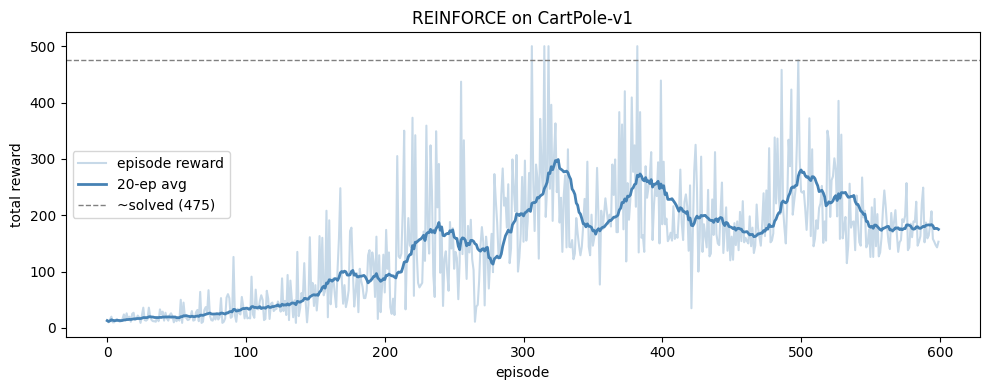

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(episode_rewards, alpha=0.3, color="steelblue", label="episode reward")
plt.plot(running_avg, color="steelblue", linewidth=2, label=f"{window}-ep avg")
plt.axhline(475, color="gray", linestyle="--", linewidth=1, label="~solved (475)")
plt.xlabel("episode")
plt.ylabel("total reward")
plt.title("REINFORCE on CartPole-v1")
plt.legend()
plt.tight_layout()
plt.show()